# 05 — Clinical-trial repeated measures with MMRM

This notebook fits a Gaussian mixed model for repeated measures (MMRM) to deterministic synthetic change-from-baseline outcomes. It demonstrates an arm-by-visit fixed-effects model, an explicit within-subject AR(1) covariance, missing-response auditing, and visit-order provenance.

## Objectives

- Build a small randomized parallel-arm longitudinal dataset.
- Represent within-subject covariance explicitly.
- Audit outcomes omitted from the likelihood because they are missing.
- Interpret arm-by-visit coefficients and the estimated visit covariance.
- Separate an educational reference fit from a confirmatory clinical analysis.

In [1]:
import importlib
import logging

import numpy as np

import pymixef

# Keep a fresh-kernel run free of Matplotlib's one-time font-cache status message.
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
plt = importlib.import_module("matplotlib.pyplot")

plt.style.use("tableau-colorblind10")

SEED = 20260705
rng = np.random.default_rng(SEED)

## Generate deterministic trial data

Twenty-four subjects are assigned alternately to control or treated arms and measured at four numeric visits. Errors are generated from a common AR(1)-like covariance. Four response values are then set to missing to exercise the audit path. In real work, missing-at-random is a scientific assumption, not a property established by software.

In [2]:
n_subjects = 24
visit_levels = np.arange(4, dtype=float)
subject_index = np.repeat(np.arange(n_subjects), len(visit_levels))
visit = np.tile(visit_levels, n_subjects)

arm_by_subject = np.array(["control" if i % 2 == 0 else "treated" for i in range(n_subjects)])
treatment = np.repeat(arm_by_subject, len(visit_levels))
treated = np.repeat((arm_by_subject == "treated").astype(float), len(visit_levels))
baseline_by_subject = rng.normal(18.0, 3.0, n_subjects)
baseline = np.repeat(baseline_by_subject, len(visit_levels))

generating_covariance = 1.4**2 * 0.55 ** np.abs(np.subtract.outer(visit_levels, visit_levels))
errors = np.concatenate(
    [
        rng.multivariate_normal(np.zeros(len(visit_levels)), generating_covariance)
        for _ in range(n_subjects)
    ]
)
change = -0.15 * baseline + 0.25 * visit + 0.30 * treated + 0.35 * treated * visit
change = change + errors
change[[7, 18, 55, 86]] = np.nan

data = {
    "change": change,
    "baseline": baseline,
    "treatment": treatment,
    "visit": visit,
    "subject": np.array([f"S{i + 1:03d}" for i in subject_index]),
}

{
    "planned_rows": len(change),
    "observed_outcomes": int(np.count_nonzero(~np.isnan(change))),
    "missing_outcomes": int(np.count_nonzero(np.isnan(change))),
}

{'planned_rows': 96, 'observed_outcomes': 92, 'missing_outcomes': 4}

## Observed change trajectories

Arm-specific means provide the first view of the repeated outcome. Error bars are descriptive 95% normal intervals for each observed mean and naturally reflect the four omitted responses.

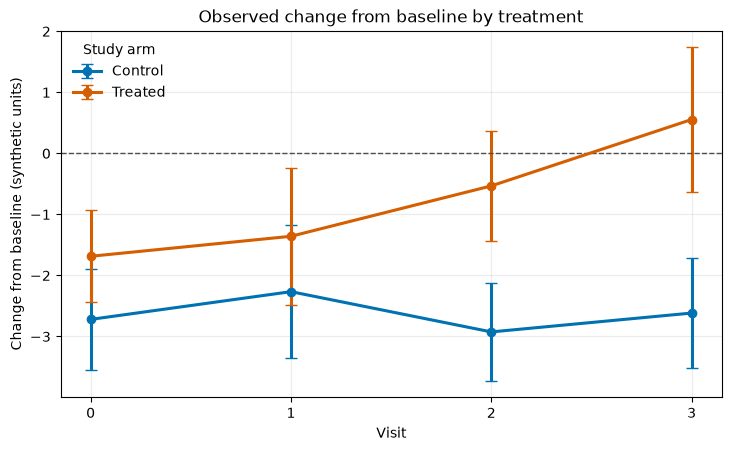

In [3]:
fig, ax = plt.subplots(figsize=(7.2, 4.4), constrained_layout=True)
arm_colors = {"control": "#0072B2", "treated": "#D55E00"}
for arm in ("control", "treated"):
    means = []
    intervals = []
    for visit_level in visit_levels:
        selected = (treatment == arm) & (visit == visit_level) & ~np.isnan(change)
        values = change[selected]
        means.append(float(np.mean(values)))
        intervals.append(float(1.96 * np.std(values, ddof=1) / np.sqrt(len(values))))
    ax.errorbar(
        visit_levels,
        means,
        yerr=intervals,
        marker="o",
        linewidth=2.2,
        capsize=4,
        color=arm_colors[arm],
        label=arm.title(),
    )
ax.axhline(0.0, color="#4D4D4D", linestyle="--", linewidth=1.0)
ax.set(
    title="Observed change from baseline by treatment",
    xlabel="Visit",
    ylabel="Change from baseline (synthetic units)",
    xticks=visit_levels,
)
ax.legend(title="Study arm", frameon=False)
ax.grid(alpha=0.25)
plt.show()

**Interpretation.** The treated arm separates progressively from control across visits, matching the generated arm-by-visit effect. MMRM formalizes that contrast while accounting for correlated observations and incomplete outcome rows.

## Declare the MMRM

The covariance declaration says that `visit` indexes measurements within `subject`. Numeric visit labels give an unambiguous ascending order. The dedicated MMRM reference path does not combine this residual covariance with formula random effects.

In [4]:
residual = pymixef.covariance.AR1(index="visit", group="subject")
model = pymixef.Model.from_formula(
    "change ~ baseline + treatment * visit",
    residual=residual,
)
plan = model.compile(
    data,
    engine="mmrm",
    method="reml",
    df_method="residual",
    maxiter=400,
    compute_hessian=False,
)
print(plan.explain())

Formula: change ~ baseline + treatment * visit
Response: change (92 analysis rows)
Fixed design: X(92, 5), rank=5, columns=['Intercept', 'baseline', 'treatment[treated]', 'visit', 'treatment[treated]:visit']
Random designs:
  none
Excluded source rows: 4
Family: gaussian (identity link)
Engine: mmrm; method: reml
Model IR: 6fa55ead1e2200c4c353e62baa4572bf00bfd875e976731ff53ac2d4977ec893
Data audit: 96 input, 92 analysis, 4 excluded; reasons={'DATA-RETAINED-001': 92, 'DATA-MISSING-RESPONSE-001': 4}


The residual degrees-of-freedom option is used here because the optional Hessian is disabled. PyMixEF also labels its available Satterthwaite and KR-inspired paths explicitly; it does not silently report the KR-inspired option as exact Kenward–Roger.

In [5]:
fit = plan.fit()
assert fit.convergence.trustworthy, fit.convergence.to_dict()
print(fit.summary())
print("\nExcluded rows:", fit.extra["data_audit"]["excluded_rows"])
print("Visit levels:", fit.extra["visit_levels"])
print("Visit-order source:", fit.extra["visit_order_source"])

PyMixEF fit (mmrm, reml)
Observations: 92
Objective: 160.4649943
Log likelihood: -160.4649943
Convergence: converged
Parameters:
  Intercept                  1.2277481
  baseline                  -0.21438179
  treatment[treated]         0.54223003
  visit                      0.011994775
  treatment[treated]:visit   0.71211688
  residual_sd                1.5519335
  ar1_correlation            0.54035337

Excluded rows: 4
Visit levels: [0.0, 1.0, 2.0, 3.0]
Visit-order source: ascending-explicit-visit-times


## Inspect the fitted within-subject covariance

For AR(1), correlations decay with visit distance while marginal variances are constant. Positive covariance eigenvalues are a basic numerical validity check.

In [6]:
visit_covariance = np.asarray(fit.extra["visit_covariance"])
covariance_eigenvalues = np.linalg.eigvalsh(visit_covariance)
assert np.all(covariance_eigenvalues > 0), "Visit covariance must be positive definite"
print("Estimated visit covariance:\n", np.round(visit_covariance, 3))
print("Eigenvalues:", np.round(covariance_eigenvalues, 6))
print("Positive-definite covariance check: passed")

Estimated visit covariance:
 [[2.408 1.301 0.703 0.38 ]
 [1.301 2.408 1.301 0.703]
 [0.703 1.301 2.408 1.301]
 [0.38  0.703 1.301 2.408]]
Eigenvalues: [0.812723 1.192278 2.322836 5.306154]
Positive-definite covariance check: passed


## Estimated visit correlation

Standardizing the fitted covariance produces an interpretable correlation matrix. The heatmap makes the assumed AR(1) distance pattern directly auditable.

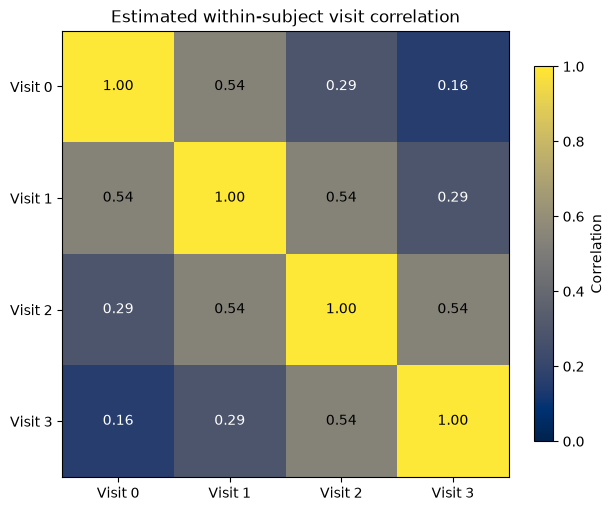

In [7]:
visit_standard_deviations = np.sqrt(np.diag(visit_covariance))
visit_correlation = (
    visit_covariance / visit_standard_deviations[:, None] / visit_standard_deviations[None, :]
)
visit_labels = [f"Visit {int(level)}" for level in fit.extra["visit_levels"]]

fig, ax = plt.subplots(figsize=(6.2, 5.0), constrained_layout=True)
image = ax.imshow(visit_correlation, vmin=0.0, vmax=1.0, cmap="cividis")
for row in range(len(visit_labels)):
    for column in range(len(visit_labels)):
        value = visit_correlation[row, column]
        ax.text(
            column,
            row,
            f"{value:.2f}",
            ha="center",
            va="center",
            color="white" if value < 0.45 else "black",
        )
ax.set_xticks(np.arange(len(visit_labels)), visit_labels)
ax.set_yticks(np.arange(len(visit_labels)), visit_labels)
ax.set(title="Estimated within-subject visit correlation")
fig.colorbar(image, ax=ax, label="Correlation", shrink=0.84)
plt.show()

**Interpretation.** Adjacent visits retain the strongest correlation and association decays with separation, as expected under AR(1). The explicit visit labels prevent adjacency from depending on input row order.

## Interpret the longitudinal treatment contrast

Treatment coding is archived in the design matrix. The coefficient named `treatment[treated]` is the treated-minus-control difference at visit 0, and its interaction with visit is the additional treated slope. The following calculation combines them at the last visit; it is a point estimate, not a confidence interval.

In [8]:
treatment_term = next(
    name for name in fit.parameters if name.startswith("treatment[") and ":" not in name
)
interaction_term = next(
    name for name in fit.parameters if name.startswith("treatment[") and ":visit" in name
)
last_visit = float(max(fit.extra["visit_levels"]))
difference_at_last_visit = (
    fit.parameters[treatment_term] + last_visit * fit.parameters[interaction_term]
)
assert difference_at_last_visit > 0, "Expected the generated positive treatment contrast"
{
    "reference-coded treatment term": treatment_term,
    "interaction term": interaction_term,
    "last visit": last_visit,
    "estimated difference at last visit": difference_at_last_visit,
    "synthetic direction check": "positive as generated",
}

{'reference-coded treatment term': 'treatment[treated]',
 'interaction term': 'treatment[treated]:visit',
 'last visit': 3.0,
 'estimated difference at last visit': 2.678580655810124,
 'synthetic direction check': 'positive as generated'}

## Model-based treatment contrast over visits

Combining the treatment main effect and treatment-by-visit coefficient gives the adjusted treated-minus-control contrast at each visit. The band uses the archived fixed-effect covariance.

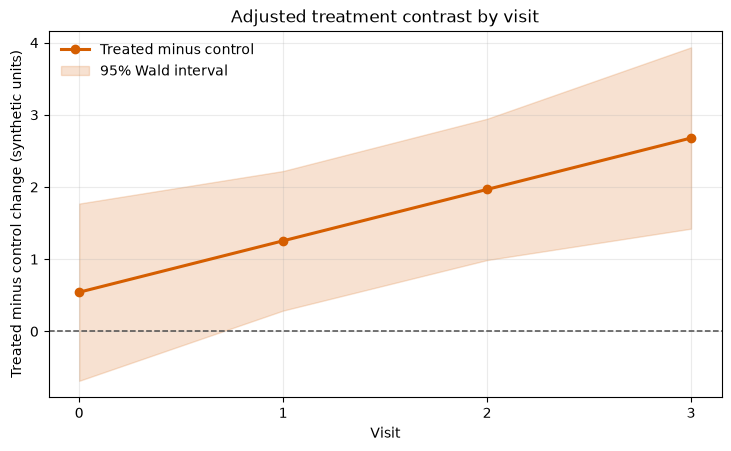

In [9]:
fixed_effect_names = list(fit.extra["fixed_effect_names"])
fixed_effect_covariance = np.asarray(fit.extra["fixed_effect_covariance"])
fixed_effect_vector = np.asarray([fit.parameters[name] for name in fixed_effect_names])
contrast_estimates = []
contrast_standard_errors = []
for visit_level in visit_levels:
    contrast = np.zeros(len(fixed_effect_names))
    contrast[fixed_effect_names.index(treatment_term)] = 1.0
    contrast[fixed_effect_names.index(interaction_term)] = visit_level
    contrast_estimates.append(float(contrast @ fixed_effect_vector))
    contrast_standard_errors.append(float(np.sqrt(contrast @ fixed_effect_covariance @ contrast)))
contrast_estimates = np.asarray(contrast_estimates)
contrast_interval = 1.96 * np.asarray(contrast_standard_errors)

fig, ax = plt.subplots(figsize=(7.2, 4.4), constrained_layout=True)
ax.plot(
    visit_levels,
    contrast_estimates,
    marker="o",
    linewidth=2.2,
    color="#D55E00",
    label="Treated minus control",
)
ax.fill_between(
    visit_levels,
    contrast_estimates - contrast_interval,
    contrast_estimates + contrast_interval,
    color="#D55E00",
    alpha=0.18,
    label="95% Wald interval",
)
ax.axhline(0.0, color="#4D4D4D", linestyle="--", linewidth=1.1)
ax.set(
    title="Adjusted treatment contrast by visit",
    xlabel="Visit",
    ylabel="Treated minus control change (synthetic units)",
    xticks=visit_levels,
)
ax.legend(frameon=False)
ax.grid(alpha=0.25)
plt.show()

**Interpretation.** The adjusted treatment difference grows with visit, and the final-visit point estimate is positive as asserted above. In a confirmatory analysis, the interval method and target visit would be prespecified.

## Scope note

This showcase uses PyMixEF's dense experimental MMRM reference path with numeric visits and homogeneous AR(1). Its transparent implementation limitations include no exact Kenward–Roger inference; a confirmatory workflow would also justify missingness and covariance assumptions, prespecify the estimand, and independently validate outputs.

## Exercises

1. Replace AR(1) with `pymixef.covariance.Unstructured(index="visit", group="subject")` and compare covariance estimates.
2. Increase missingness in one arm and discuss why model convergence does not resolve missing-data bias.
3. Use nonnumeric visit labels and provide an explicit scientific order before fitting an order-dependent covariance.
4. Re-enable the Hessian and use the explicitly labeled Satterthwaite option on this small dataset.